In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

%matplotlib inline

In [2]:
df = pd.read_csv('wine.csv')

In [3]:
df.shape

(178, 14)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Type             178 non-null    int64  
 1   Alcohol          178 non-null    float64
 2   Malic            178 non-null    float64
 3   Ash              178 non-null    float64
 4   Alcalinity       178 non-null    float64
 5   Magnesium        178 non-null    int64  
 6   Phenols          178 non-null    float64
 7   Flavanoids       178 non-null    float64
 8   Nonflavanoids    178 non-null    float64
 9   Proanthocyanins  178 non-null    float64
 10  Color            178 non-null    float64
 11  Hue              178 non-null    float64
 12  Dilution         178 non-null    float64
 13  Proline          178 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 19.6 KB


In [5]:
df.describe()

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,1.938202,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.775035,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,1.000000,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,1.000000,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,2.000000,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,3.000000,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,3.000000,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


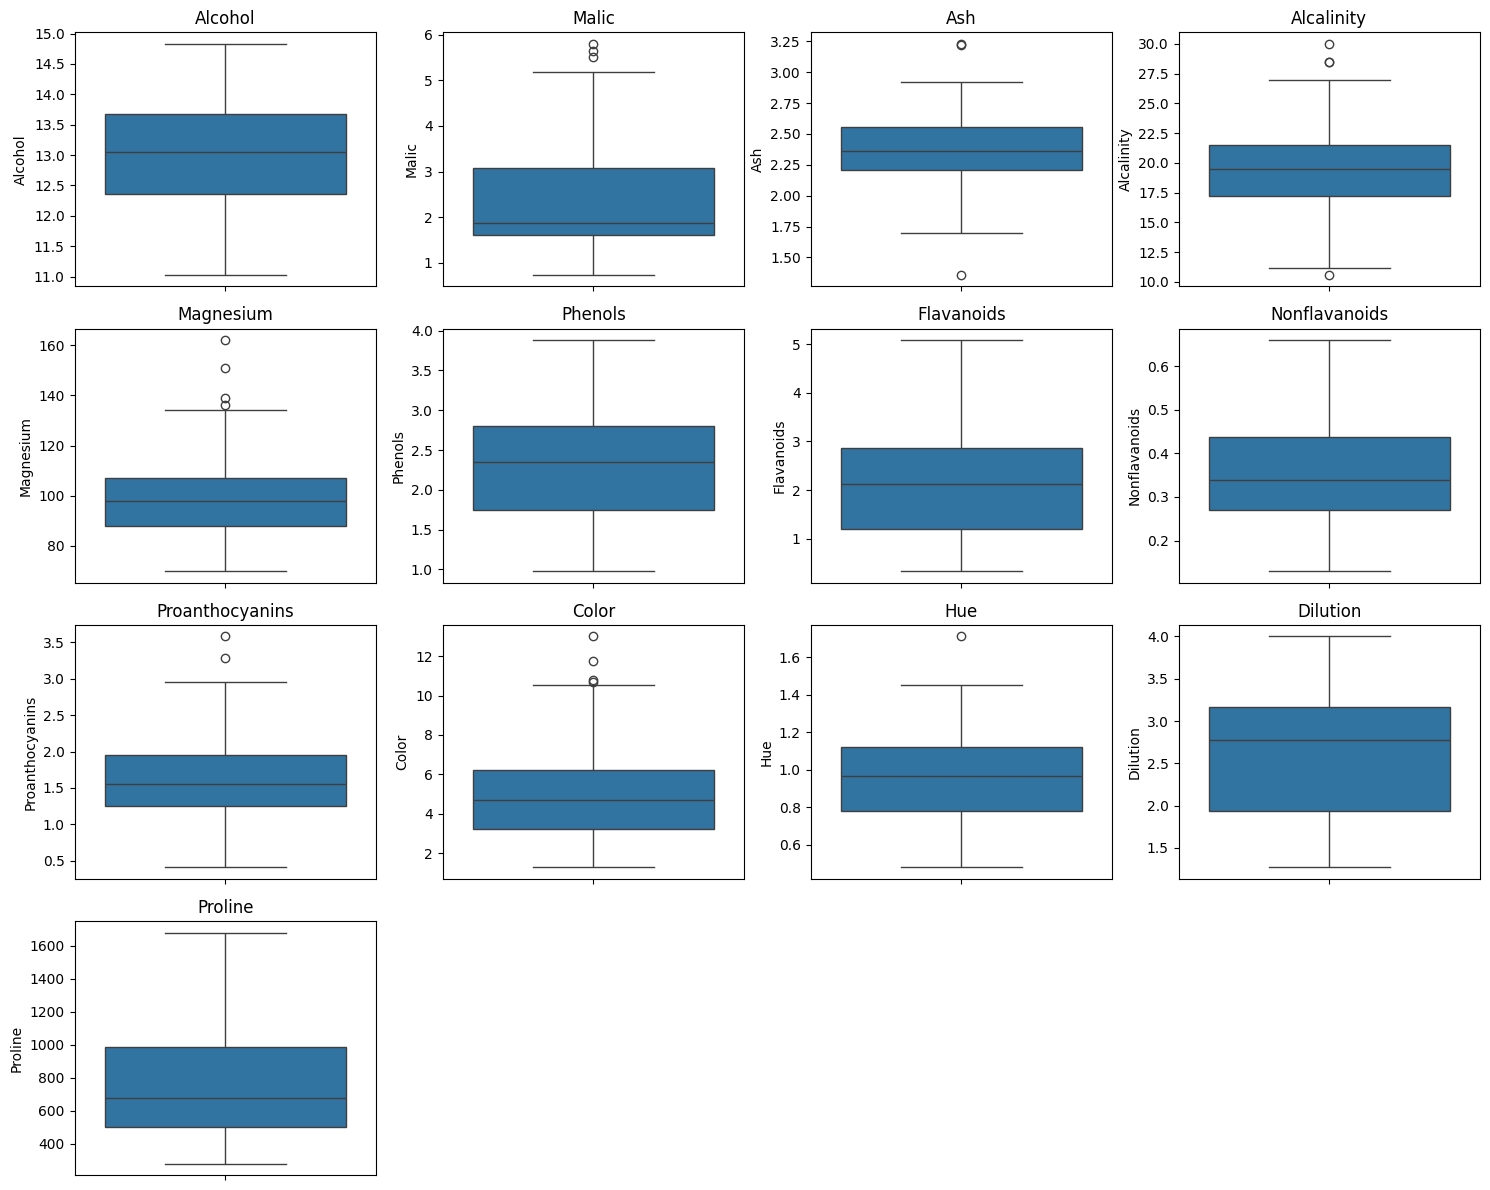

In [6]:
fig, axes = plt.subplots(4, 4, figsize=(15, 12))
cols = df.columns[1:]
for i, col in enumerate(cols):
    row, c = divmod(i, 4)
    sns.boxplot(y=df[col], ax=axes[row, c])
    axes[row, c].set_title(col)

for i in range(len(cols), 16):
    row, c = divmod(i, 4)
    axes[row, c].axis('off')

plt.tight_layout()
plt.show()

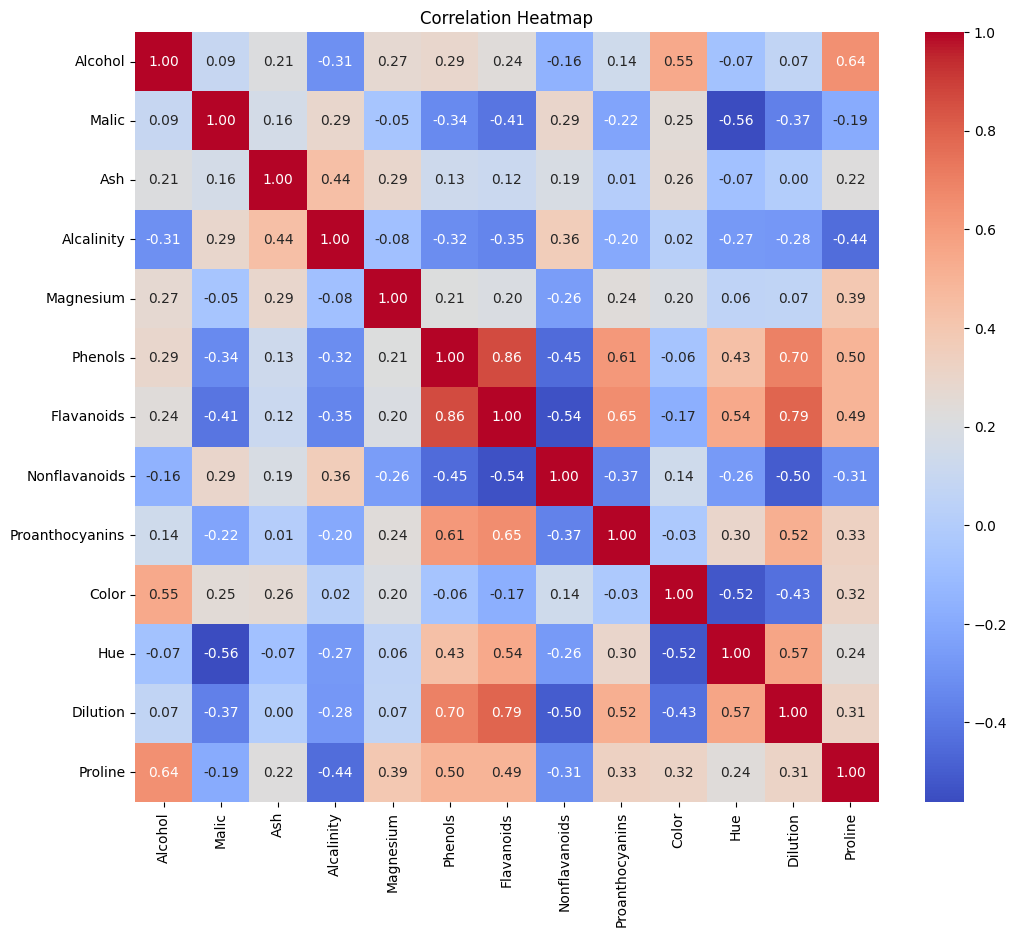

In [7]:
plt.figure(figsize=(12, 10))
sns.heatmap(df.drop(columns='Type').corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

In [8]:
x = df.drop(columns='Type')
y = df['Type']
sc = StandardScaler()
x_scaled = sc.fit_transform(x)

In [9]:
pca = PCA()
pca.fit(x_scaled)
explained_var = pca.explained_variance_ratio_
cum_var = np.cumsum(explained_var)

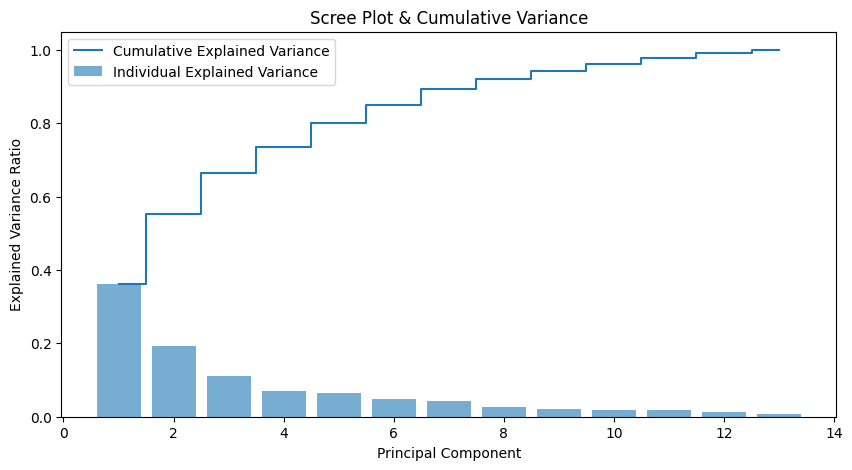

In [10]:
plt.figure(figsize=(10, 5))
plt.bar(range(1, len(explained_var)+1), explained_var, alpha=0.6, label='Individual Explained Variance')
plt.step(range(1, len(cum_var)+1), cum_var, where='mid', label='Cumulative Explained Variance')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Scree Plot & Cumulative Variance')
plt.legend()
plt.show()

In [11]:
pca_opt = PCA(n_components=3)
x_pca = pca_opt.fit_transform(x_scaled)
print("PCA shape:", x_pca.shape)
print("Cumulative variance explained by 3 components:", cum_var[2])

PCA shape: (178, 3)
Cumulative variance explained by 3 components: 0.6652996889318525


In [12]:
kmeans_orig = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_orig = kmeans_orig.fit_predict(x_scaled)
sil_orig = silhouette_score(x_scaled, labels_orig)
db_orig = davies_bouldin_score(x_scaled, labels_orig)

print(f"Original Data - Silhouette Score: {sil_orig:.4f}")
print(f"Original Data - Davies-Bouldin Index: {db_orig:.4f}")

Original Data - Silhouette Score: 0.2849
Original Data - Davies-Bouldin Index: 1.3892


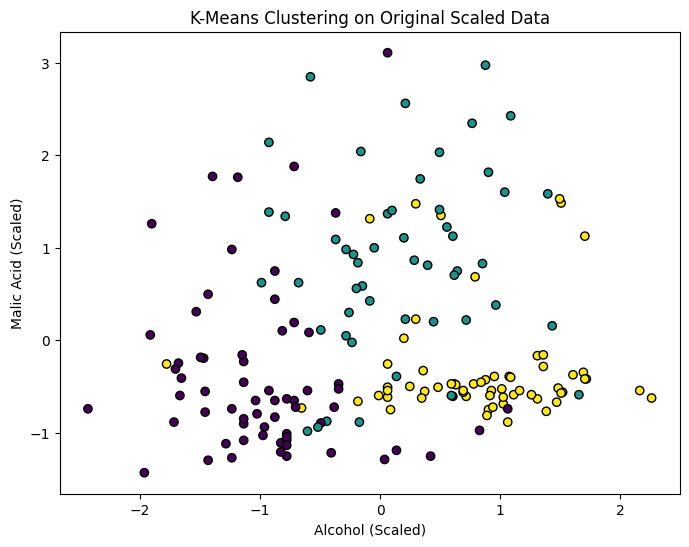

In [13]:
plt.figure(figsize=(8, 6))
plt.scatter(x_scaled[:, 0], x_scaled[:, 1], c=labels_orig, cmap='viridis', edgecolors='k')
plt.title('K-Means Clustering on Original Scaled Data')
plt.xlabel('Alcohol (Scaled)')
plt.ylabel('Malic Acid (Scaled)')
plt.show()

In [14]:
kmeans_pca = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_pca = kmeans_pca.fit_predict(x_pca)
sil_pca = silhouette_score(x_pca, labels_pca)
db_pca = davies_bouldin_score(x_pca, labels_pca)

print(f"PCA-Transformed Data - Silhouette Score: {sil_pca:.4f}")
print(f"PCA-Transformed Data - Davies-Bouldin Index: {db_pca:.4f}")

PCA-Transformed Data - Silhouette Score: 0.4532
PCA-Transformed Data - Davies-Bouldin Index: 0.8400


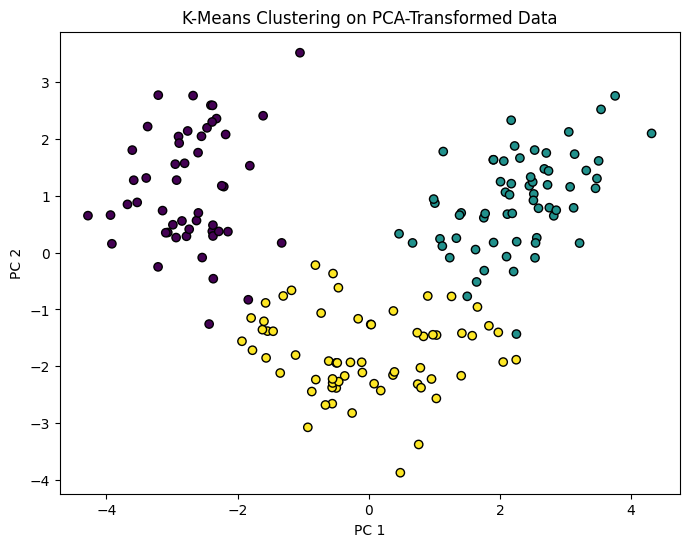

In [15]:
plt.figure(figsize=(8, 6))
plt.scatter(x_pca[:, 0], x_pca[:, 1], c=labels_pca, cmap='viridis', edgecolors='k')
plt.title('K-Means Clustering on PCA-Transformed Data')
plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.show()

In [16]:
comp_df = pd.DataFrame({
    'Dataset': ['Original Scaled', 'PCA-Transformed (3 PCs)'],
    'Silhouette Score': [sil_orig, sil_pca],
    'Davies-Bouldin Index': [db_orig, db_pca]
})
print(comp_df)

                   Dataset  Silhouette Score  Davies-Bouldin Index
0          Original Scaled          0.284859              1.389188
1  PCA-Transformed (3 PCs)          0.453235              0.839971


In [17]:
pd.crosstab(y, labels_orig, colnames=['Cluster_Orig'])

Cluster_Orig,0,1,2
Type,,,
1,0,0,59
2,65,3,3
3,0,48,0


In [18]:
pd.crosstab(y, labels_pca, colnames=['Cluster_PCA'])

Cluster_PCA,0,1,2
Type,,,
1,0,59,0
2,3,4,64
3,48,0,0
